In [10]:
import pandas as pd
import numpy as np

df = pd.read_csv("creditcard.csv")

print(df.shape)           # (284807, 31)
print(df.dtypes)
print(df.isnull().sum())  # should be zero — dataset is clean

# ⚠️ PITFALL: class imbalance — ~0.17% fraud
print(df["Class"].value_counts(normalize=True))

(284807, 31)
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64
Class
0    0.998273
1    0.001

In [4]:
!pip install imbalanced-learn

## Data Preprocessing

In [11]:
print(df.columns)

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')


In [12]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Scale Amount and Time (V1-V28 are already PCA-transformed)
scaler = StandardScaler()
df["scaled_amount"] = scaler.fit_transform(df[["Amount"]])
df["scaled_time"]   = scaler.fit_transform(df[["Time"]])
df.drop(["Amount", "Time"], axis=1, inplace=True)

X = df.drop("Class", axis=1)
y = df["Class"]

# Stratified split — preserves fraud ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ⚠️ PITFALL: apply SMOTE ONLY on train set, never before splitting
# Applying it before split = data leakage
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

In [16]:
import time
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# UK grid carbon intensity (gCO2e per kWh) — from National Grid ESO 2024
UK_CARBON_INTENSITY = 0.233  # kg CO2e per kWh
CPU_TDP_WATTS       = 65     # typical laptop CPU — adjust if you know your hardware

def estimate_emissions(runtime_seconds, tdp_watts=CPU_TDP_WATTS, carbon_intensity=UK_CARBON_INTENSITY):
    """
    Estimate energy and CO2e from runtime using TDP-based formula.

    Formula from datathon guide:
        kWh     = Runtime (hours) × Average Power (kW)
        CO2e    = kWh × Grid Carbon Intensity
    """
    kwh  = (runtime_seconds / 3600) * (tdp_watts / 1000)
    co2e = kwh * carbon_intensity
    return kwh, co2e

# Usage — wrap any block you want to measure
t0 = time.time()

# --- your model training code here ---
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_train_res, y_train_res)

runtime = time.time() - t0
kwh_train, co2e_train = estimate_emissions(runtime)

print(f"Runtime:          {runtime:.2f}s")
print(f"Energy consumed:  {kwh_train*1000:.4f} Wh  ({kwh_train:.6f} kWh)")
print(f"CO2e emitted:     {co2e_train*1000:.6f} g  ({co2e_train:.8f} kg)")

Runtime:          7.31s
Energy consumed:  0.1319 Wh  (0.000132 kWh)
CO2e emitted:     0.030736 g  (0.00003074 kg)


In [17]:
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]
auc_lr = roc_auc_score(y_test, y_prob_lr)
print(classification_report(y_test, y_pred_lr))
print(f"AUC: {auc_lr:.4f}")
print(f"CO₂e (kg): {co2e_train:.6f}")

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962

AUC: 0.9698
CO₂e (kg): 0.000031


## Try model

In [18]:
!pip install sentencepiece

In [19]:
def row_to_prompt(row):
    features = ", ".join([f"{col}: {row[col]:.4f}" for col in X.columns])
    return f"Transaction features: {features}. Is this a fraudulent transaction? Answer yes or no."

# ⚠️ PITFALL: flan-t5-base has a 512-token input limit
# 30 features × ~8 tokens each ≈ 240 tokens — you're fine, but always verify:
from transformers import T5Tokenizer
tokenizer = T5Tokenizer.from_pretrained("google/flan-t5-base")

sample_prompt = row_to_prompt(X_test.iloc[0])
tokens = tokenizer(sample_prompt, return_tensors="pt")
print(f"Token length: {tokens['input_ids'].shape[1]}")  # should be < 512

X_test_prompts  = [row_to_prompt(X_test.iloc[i]) for i in range(len(X_test))]
X_train_prompts = [row_to_prompt(X_train_res.iloc[i]) for i in range(len(X_train_res))]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

Token length: 248


In [20]:
from transformers import T5ForConditionalGeneration, T5Tokenizer, Trainer, TrainingArguments
from torch.utils.data import Dataset
import torch

class FraudDataset(Dataset):
    def __init__(self, prompts, labels, tokenizer, max_len=256):
        self.encodings = tokenizer(prompts, truncation=True, padding="max_length",
                                   max_length=max_len, return_tensors="pt")
        # flan-t5 outputs text — label "yes" or "no"
        label_text = ["yes" if l == 1 else "no" for l in labels]
        self.labels = tokenizer(label_text, return_tensors="pt",
                                padding="max_length", max_length=4).input_ids
        self.labels[self.labels == tokenizer.pad_token_id] = -100  # ignore padding in loss

    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        return {k: v[idx] for k, v in self.encodings.items()} | {"labels": self.labels[idx]}

tokenizer = T5Tokenizer.from_pretrained("google/flan-t5-base")
model     = T5ForConditionalGeneration.from_pretrained("google/flan-t5-base")

# ⚠️ PITFALL: fine-tuning on the full resampled train set is expensive
# Use a stratified subsample for experimentation — e.g. 5,000 rows each class
from sklearn.utils import resample
idx_fraud = y_train_res[y_train_res==1].index[:5000]
idx_legit = y_train_res[y_train_res==0].index[:5000]
idx_sub   = idx_fraud.append(idx_legit)

train_ds = FraudDataset(
    [row_to_prompt(X_train_res.loc[i]) for i in idx_sub],
    y_train_res.loc[idx_sub].tolist(), tokenizer
)
# Use full test set for fair evaluation
test_ds = FraudDataset(X_test_prompts, y_test.tolist(), tokenizer)

args = TrainingArguments(
    output_dir="./flan-t5-fraud",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    eval_strategy="epoch",
    save_strategy="no",
    logging_steps=50,
    fp16=torch.cuda.is_available(),  # mixed precision if GPU available
)


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

NameError: name 'EmissionsTracker' is not defined

In [21]:

# ── Training ─────────────────────────────────────────────────────────────────
t0_t5_train = time.time()

trainer = Trainer(model=model, args=args, train_dataset=train_ds, eval_dataset=test_ds)
trainer.train()

runtime_t5_train = time.time() - t0_t5_train
kwh_t5_train, co2_t5_train = estimate_emissions(runtime_t5_train)

print(f"Runtime:         {runtime_t5_train:.2f}s")
print(f"Energy consumed: {kwh_t5_train*1000:.4f} Wh  ({kwh_t5_train:.6f} kWh)")
print(f"CO2e emitted:    {co2_t5_train*1000:.6f} g  ({co2_t5_train:.8f} kg)")

Epoch,Training Loss,Validation Loss
1,0.000000,nan
2,0.000000,nan
3,0.000000,nan


Runtime:         2607.88s
Energy consumed: 47.0868 Wh  (0.047087 kWh)
CO2e emitted:    10.971220 g  (0.01097122 kg)


In [23]:
def predict_t5(prompts, model, tokenizer, batch_size=32):
    preds = []
    model.eval()
    for i in range(0, len(prompts), batch_size):
        batch = tokenizer(prompts[i:i+batch_size], return_tensors="pt",
                          truncation=True, padding=True, max_length=256)
        with torch.no_grad():
            out = model.generate(**batch, max_new_tokens=3)
        decoded = tokenizer.batch_decode(out, skip_special_tokens=True)
        preds += [1 if "yes" in d.lower() else 0 for d in decoded]
    return preds

y_pred_t5 = predict_t5(X_test_prompts, model, tokenizer)
auc_t5 = roc_auc_score(y_test, y_pred_t5)  # binary — no prob score
print(classification_report(y_test, y_pred_t5))
print(f"AUC: {auc_t5:.4f} | CO₂e: {emissions_t5:.6f} kg")

KeyboardInterrupt: 

In [ ]:
import pandas as pd

results = {
    "Model":       ["Logistic Regression", "flan-t5-base"],
    "AUC":         [auc_lr,  auc_t5],
    "CO2e_kg":     [emissions_lr, emissions_t5],
}
df_results = pd.DataFrame(results)

# Normalise both to [0,1]
df_results["norm_auc"]  = (df_results["AUC"]    - df_results["AUC"].min()) / (df_results["AUC"].max() - df_results["AUC"].min() + 1e-9)
df_results["norm_co2"]  = (df_results["CO2e_kg"] - df_results["CO2e_kg"].min()) / (df_results["CO2e_kg"].max() - df_results["CO2e_kg"].min() + 1e-9)

# Datathon formula
df_results["efficiency_score"] = df_results["norm_auc"] / (df_results["norm_co2"] + 1e-9)
# Or weighted: 0.7 * norm_auc - 0.3 * norm_co2
df_results["hackathon_score"] = 0.7 * df_results["norm_auc"] - 0.3 * df_results["norm_co2"]

print(df_results.sort_values("hackathon_score", ascending=False).to_string(index=False))

## Restart

## Imports & setup

In [24]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import torch

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, roc_auc_score,
    f1_score, precision_score, recall_score,
    confusion_matrix, RocCurveDisplay
)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
RANDOM_STATE = 42

print("✅ Imports complete")

✅ Imports complete


## Carbon estimator

In [25]:
UK_CARBON_INTENSITY = 0.233  # kg CO2e per kWh — National Grid ESO 2024
CPU_TDP_WATTS       = 65     # adjust to your hardware TDP

def estimate_emissions(runtime_seconds,
                        tdp_watts=CPU_TDP_WATTS,
                        carbon_intensity=UK_CARBON_INTENSITY):
    """
    Formula from datathon guide:
        kWh  = Runtime (hours) × Average Power (kW)
        CO2e = kWh × Grid Carbon Intensity
    """
    kwh  = (runtime_seconds / 3600) * (tdp_watts / 1000)
    co2e = kwh * carbon_intensity
    return kwh, co2e

print(f"✅ Estimator ready — TDP: {CPU_TDP_WATTS}W | CI: {UK_CARBON_INTENSITY} kgCO2e/kWh")

✅ Estimator ready — TDP: 65W | CI: 0.233 kgCO2e/kWh


## Load & inspect dataset

In [26]:
df = pd.read_csv('creditcard.csv')

print(f"Shape: {df.shape}")
print(f"\nClass distribution:")
print(df['Class'].value_counts())
print(f"\nFraud rate: {df['Class'].mean()*100:.4f}%")
print(f"Missing values: {df.isnull().sum().sum()}")

df.head(3)

Shape: (284807, 31)

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud rate: 0.1727%
Missing values: 0


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0


## EDA plots

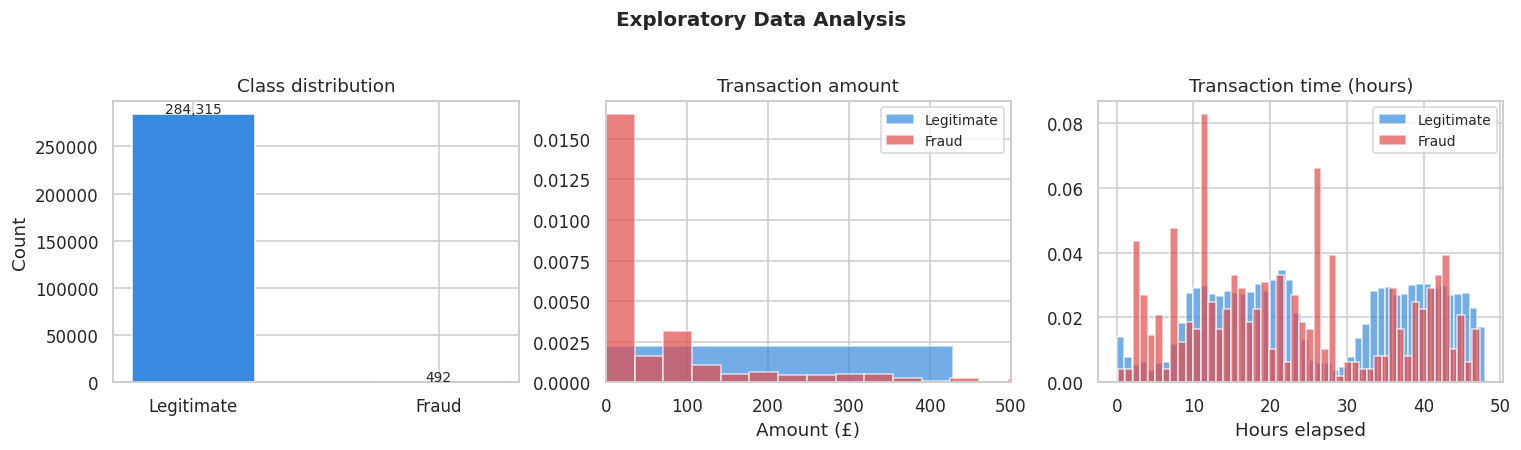

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

counts = df['Class'].value_counts()
axes[0].bar(['Legitimate', 'Fraud'], counts.values,
            color=['#378ADD', '#E24B4A'], width=0.5)
axes[0].set_title('Class distribution', fontsize=12)
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontsize=9)

axes[1].hist(df[df['Class']==0]['Amount'], bins=60, alpha=0.7,
             color='#378ADD', label='Legitimate', density=True)
axes[1].hist(df[df['Class']==1]['Amount'], bins=60, alpha=0.7,
             color='#E24B4A', label='Fraud', density=True)
axes[1].set_title('Transaction amount', fontsize=12)
axes[1].set_xlabel('Amount (£)')
axes[1].set_xlim(0, 500)
axes[1].legend(fontsize=9)

axes[2].hist(df[df['Class']==0]['Time']/3600, bins=48, alpha=0.7,
             color='#378ADD', label='Legitimate', density=True)
axes[2].hist(df[df['Class']==1]['Time']/3600, bins=48, alpha=0.7,
             color='#E24B4A', label='Fraud', density=True)
axes[2].set_title('Transaction time (hours)', fontsize=12)
axes[2].set_xlabel('Hours elapsed')
axes[2].legend(fontsize=9)

plt.suptitle('Exploratory Data Analysis', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Preprocessing

In [28]:
df_clean = df.copy()

scaler = StandardScaler()
df_clean['scaled_amount'] = scaler.fit_transform(df_clean[['Amount']])
df_clean['scaled_time']   = scaler.fit_transform(df_clean[['Time']])
df_clean.drop(['Amount', 'Time'], axis=1, inplace=True)

X = df_clean.drop('Class', axis=1)
y = df_clean['Class']

# Stratified split — preserves fraud ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train: {X_train.shape[0]:,} rows | fraud rate: {y_train.mean()*100:.4f}%")
print(f"Test:  {X_test.shape[0]:,} rows  | fraud rate: {y_test.mean()*100:.4f}%")

Train: 227,845 rows | fraud rate: 0.1729%
Test:  56,962 rows  | fraud rate: 0.1720%


## SMOTE

In [29]:
from imblearn.over_sampling import SMOTE

# ⚠️ SMOTE applied ONLY on train set — never before splitting
sm = SMOTE(random_state=RANDOM_STATE)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print(f"After SMOTE — train size: {len(X_train_res):,}")
print(f"Class balance: {pd.Series(y_train_res).value_counts().to_dict()}")
print("✅ Test set untouched — no leakage")

After SMOTE — train size: 454,902
Class balance: {0: 227451, 1: 227451}
✅ Test set untouched — no leakage


## Baseline: Logistic Regression

In [30]:
t0_lr_train = time.time()

lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=RANDOM_STATE
)
lr.fit(X_train_res, y_train_res)

runtime_lr_train            = time.time() - t0_lr_train
kwh_lr_train, co2_lr_train  = estimate_emissions(runtime_lr_train)

# Inference
t0_lr_inf = time.time()
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]
runtime_lr_inf              = time.time() - t0_lr_inf
kwh_lr_inf, co2_lr_inf      = estimate_emissions(runtime_lr_inf)

# Metrics
auc_lr       = roc_auc_score(y_test, y_prob_lr)
f1_lr        = f1_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr    = recall_score(y_test, y_pred_lr)

print("=== Logistic Regression ===")
print(f"AUC-ROC:   {auc_lr:.4f}")
print(f"F1:        {f1_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall:    {recall_lr:.4f}")
print(f"\nTrain  — {runtime_lr_train:.2f}s | {kwh_lr_train*1000:.4f} Wh | {co2_lr_train*1000:.6f} g CO2e")
print(f"Infer  — {runtime_lr_inf:.4f}s  | {kwh_lr_inf*1000:.6f} Wh | {co2_lr_inf*1000:.6f} g CO2e")
print(f"CO2e per 1k preds: {co2_lr_inf/len(y_test)*1000*1000:.6f} g")
print(classification_report(y_test, y_pred_lr, target_names=['Legitimate','Fraud']))

=== Logistic Regression ===
AUC-ROC:   0.9698
F1:        0.1094
Precision: 0.0581
Recall:    0.9184

Train  — 5.24s | 0.0946 Wh | 0.022038 g CO2e
Infer  — 0.0359s  | 0.000649 Wh | 0.000151 g CO2e
CO2e per 1k preds: 0.000003 g
              precision    recall  f1-score   support

  Legitimate       1.00      0.97      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



## Logistic Regression plots

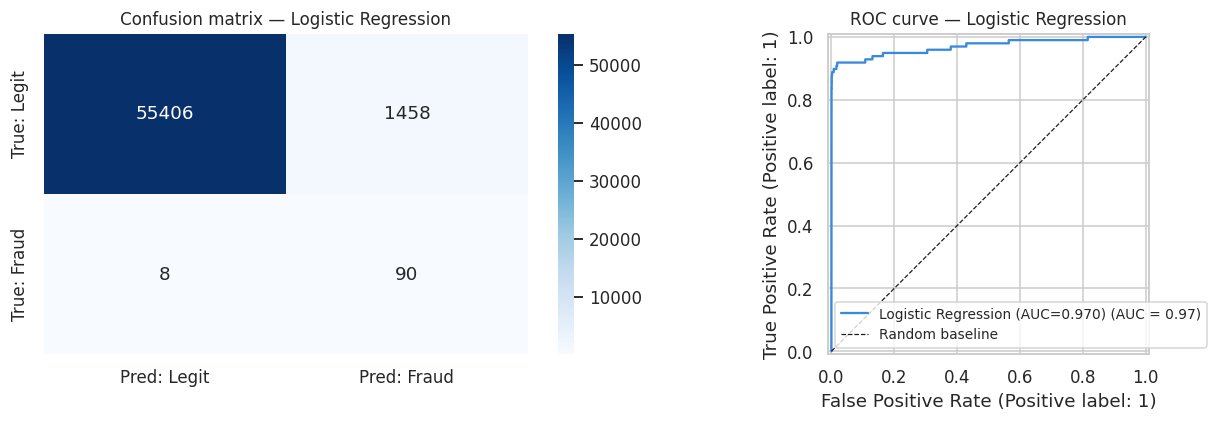

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Pred: Legit', 'Pred: Fraud'],
            yticklabels=['True: Legit', 'True: Fraud'])
axes[0].set_title('Confusion matrix — Logistic Regression', fontsize=11)

RocCurveDisplay.from_predictions(
    y_test, y_prob_lr, ax=axes[1],
    name=f'Logistic Regression (AUC={auc_lr:.3f})',
    color='#378ADD'
)
axes[1].plot([0,1],[0,1],'k--', lw=0.8, label='Random baseline')
axes[1].set_title('ROC curve — Logistic Regression', fontsize=11)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('lr_evaluation.png', dpi=130, bbox_inches='tight')
plt.show()

In [32]:
# !pip install transformers torch sentencepiece accelerate  # run once

from transformers import (
    AutoTokenizer, T5ForConditionalGeneration,
    Trainer, TrainingArguments
)
from torch.utils.data import Dataset

print("✅ Transformers ready")

✅ Transformers ready


##  Build small dataset (

In [33]:
def row_to_prompt(row):
    features = ", ".join([f"{col}: {row[col]:.4f}" for col in X.columns])
    return (f"Transaction features: {features}. "
            f"Is this a fraudulent transaction? Answer yes or no.")

tokenizer = AutoTokenizer.from_pretrained("google/flan-t5-base")

# Verify token length stays under 512
sample_lengths = [
    tokenizer(row_to_prompt(X_test.iloc[i]),
              return_tensors='pt')['input_ids'].shape[1]
    for i in range(min(200, len(X_test)))
]
print(f"Token lengths — min: {np.min(sample_lengths)}, "
      f"max: {np.max(sample_lengths)}, "
      f"mean: {np.mean(sample_lengths):.1f}")

if np.max(sample_lengths) > 512:
    print("⚠️  Truncation will occur — reduce decimal places")
else:
    print("✅ All prompts within 512-token limit")

Token lengths — min: 239, max: 259, mean: 249.3
✅ All prompts within 512-token limit


##  Build small dataset (

In [34]:
# ── Subsample — 300 fraud + 300 legit for fast training ──────────────────────
N_FRAUD = 300
N_LEGIT = 300

X_tr_df = pd.DataFrame(X_train_res, columns=X.columns)
y_tr_s  = pd.Series(
    y_train_res.values if hasattr(y_train_res, 'values') else y_train_res
)

idx_fraud = y_tr_s[y_tr_s == 1].index[:N_FRAUD]
idx_legit = y_tr_s[y_tr_s == 0].index[:N_LEGIT]
idx_sub   = idx_fraud.append(idx_legit)

X_sub = X_tr_df.loc[idx_sub].reset_index(drop=True)
y_sub = y_tr_s.loc[idx_sub].reset_index(drop=True)

print(f"Training samples: {len(X_sub)} ({N_FRAUD} fraud + {N_LEGIT} legit)")
print(f"Class balance: {y_sub.value_counts().to_dict()}")

# Build prompts
X_sub_prompts  = [row_to_prompt(X_sub.iloc[i])  for i in range(len(X_sub))]
X_test_prompts = [row_to_prompt(X_test.iloc[i])  for i in range(len(X_test))]

print(f"Train prompts: {len(X_sub_prompts):,}")
print(f"Test prompts:  {len(X_test_prompts):,}")

Training samples: 600 (300 fraud + 300 legit)
Class balance: {1: 300, 0: 300}
Train prompts: 600
Test prompts:  56,962


## Dataset class

In [35]:
class FraudTextDataset(Dataset):
    """
    Encodes each sample individually at __getitem__ time.
    Avoids the -100 masking / nan loss issue from batch padding.
    """
    def __init__(self, prompts, labels, tokenizer, max_input_len=256):
        self.prompts     = prompts
        self.label_texts = ['yes' if l == 1 else 'no' for l in labels]
        self.tokenizer   = tokenizer
        self.max_len     = max_input_len

    def __len__(self):
        return len(self.prompts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.prompts[idx],
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )
        lbl = self.tokenizer(
            self.label_texts[idx],
            return_tensors='pt'
        ).input_ids.squeeze()

        return {
            'input_ids':      enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'labels':         lbl,
        }

train_ds = FraudTextDataset(X_sub_prompts,  y_sub.tolist(),   tokenizer)
test_ds  = FraudTextDataset(X_test_prompts, y_test.tolist(),  tokenizer)

# Sanity check — labels must NOT be all -100
sample = train_ds[0]
print("Label tokens:", sample['labels'])
print("Decoded label:", tokenizer.decode(sample['labels']))
# Should print "yes" or "no"

Label tokens: tensor([4273,    1])
Decoded label: yes</s>


## Train flan-t5

In [36]:
model = T5ForConditionalGeneration.from_pretrained("google/flan-t5-base")

args = TrainingArguments(
    output_dir="./flan-t5-fraud",
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    eval_strategy="epoch",
    save_strategy="no",
    logging_steps=10,
    fp16=torch.cuda.is_available(),
    report_to="none",
)

t0_t5_train = time.time()

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
)
trainer.train()

runtime_t5_train                = time.time() - t0_t5_train
kwh_t5_train, co2_t5_train      = estimate_emissions(runtime_t5_train)

print(f"\nRuntime:         {runtime_t5_train:.2f}s")
print(f"Energy:          {kwh_t5_train*1000:.4f} Wh  ({kwh_t5_train:.6f} kWh)")
print(f"CO2e:            {co2_t5_train*1000:.6f} g  ({co2_t5_train:.8f} kg)")

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Epoch,Training Loss,Validation Loss
1,0.000000,nan
2,0.000000,nan



Runtime:         1043.76s
Energy:          18.8456 Wh  (0.018846 kWh)
CO2e:            4.391020 g  (0.00439102 kg)


## Inference

In [39]:
from sklearn.utils import resample

# Subsample test set — stratified to preserve fraud ratio
X_test_small, y_test_small = resample(
    X_test, y_test,
    n_samples=1000,
    stratify=y_test,
    random_state=42
)

X_test_prompts_small = [row_to_prompt(X_test_small.iloc[i])
                         for i in range(len(X_test_small))]

print(f"Test subsample: {len(X_test_small)} rows")
print(f"Fraud rate: {y_test_small.mean()*100:.3f}%")

# ── Inference ─────────────────────────────────────────────────────────────────
def predict_t5(prompts, model, tokenizer, batch_size=32):
    preds  = []
    device = next(model.parameters()).device
    model.eval()
    for i in range(0, len(prompts), batch_size):
        batch = tokenizer(
            prompts[i:i+batch_size],
            return_tensors='pt',
            truncation=True,
            padding=True,
            max_length=256
        )
        batch = {k: v.to(device) for k, v in batch.items()}
        with torch.no_grad():
            out = model.generate(**batch, max_new_tokens=3)
        decoded = tokenizer.batch_decode(out, skip_special_tokens=True)
        preds += [1 if "yes" in d.lower() else 0 for d in decoded]
    return preds

t0_t5_inf = time.time()
y_pred_t5 = predict_t5(X_test_prompts_small, model, tokenizer)
runtime_t5_inf         = time.time() - t0_t5_inf
kwh_t5_inf, co2_t5_inf = estimate_emissions(runtime_t5_inf)
co2_per_1k_t5          = (co2_t5_inf / len(y_test_small)) * 1000 * 1000

# ── Metrics ───────────────────────────────────────────────────────────────────
auc_t5       = roc_auc_score(y_test_small, y_pred_t5)
f1_t5        = f1_score(y_test_small, y_pred_t5)
precision_t5 = precision_score(y_test_small, y_pred_t5)
recall_t5    = recall_score(y_test_small, y_pred_t5)

print(f"AUC: {auc_t5:.4f} | F1: {f1_t5:.4f}")
print(f"Runtime: {runtime_t5_inf:.2f}s")
print(f"CO2e inference: {co2_t5_inf*1000:.6f} g")
print(f"CO2e per 1k preds: {co2_per_1k_t5:.6f} g")
print(classification_report(y_test_small, y_pred_t5,
                             target_names=['Legitimate', 'Fraud']))

Test subsample: 1000 rows
Fraud rate: 0.200%
AUC: 0.5000 | F1: 0.0000
Runtime: 19.91s
CO2e inference: 0.083760 g
CO2e per 1k preds: 0.083760 g
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00       998
       Fraud       0.00      0.00      0.00         2

    accuracy                           1.00      1000
   macro avg       0.50      0.50      0.50      1000
weighted avg       1.00      1.00      1.00      1000



## Leaderboard

In [44]:
EPS = 1e-9

results = pd.DataFrame({
    'Model':             ['Logistic Regression', 'flan-t5-base (n=600, undertrained)'],
    'AUC':               [auc_lr,                auc_t5],
    'F1':                [f1_lr,                 f1_t5],
    'Precision':         [precision_lr,          precision_t5],
    'Recall':            [recall_lr,             recall_t5],
    'CO2e_train_kg':     [co2_lr_train,          co2_t5_train],
    'CO2e_inference_kg': [co2_lr_inf,            co2_t5_inf],
    'kWh_train':         [kwh_lr_train,          kwh_t5_train],
})

results['CO2e_total_kg']     = results['CO2e_train_kg'] + results['CO2e_inference_kg']
results['CO2e_per_1k_preds'] = results['CO2e_inference_kg'] / 1000 * 1000 * 1000
results['norm_AUC'] = (results['AUC'] - results['AUC'].min()) / \
                      (results['AUC'].max() - results['AUC'].min() + EPS)
results['norm_CO2'] = (results['CO2e_total_kg'] - results['CO2e_total_kg'].min()) / \
                      (results['CO2e_total_kg'].max() - results['CO2e_total_kg'].min() + EPS)
results['score_hackathon'] = 0.7 * results['norm_AUC'] - 0.3 * results['norm_CO2']

print("=== Leaderboard ===")
print(results[['Model','AUC','F1','CO2e_total_kg','score_hackathon']]
      .sort_values('score_hackathon', ascending=False)
      .to_string(index=False))

=== Leaderboard ===
                             Model      AUC       F1  CO2e_total_kg  score_hackathon
               Logistic Regression 0.969848 0.109356   4.857930e-07              0.7
flan-t5-base (n=600, undertrained) 0.500000 0.000000   4.474780e-03             -0.3


## Charts

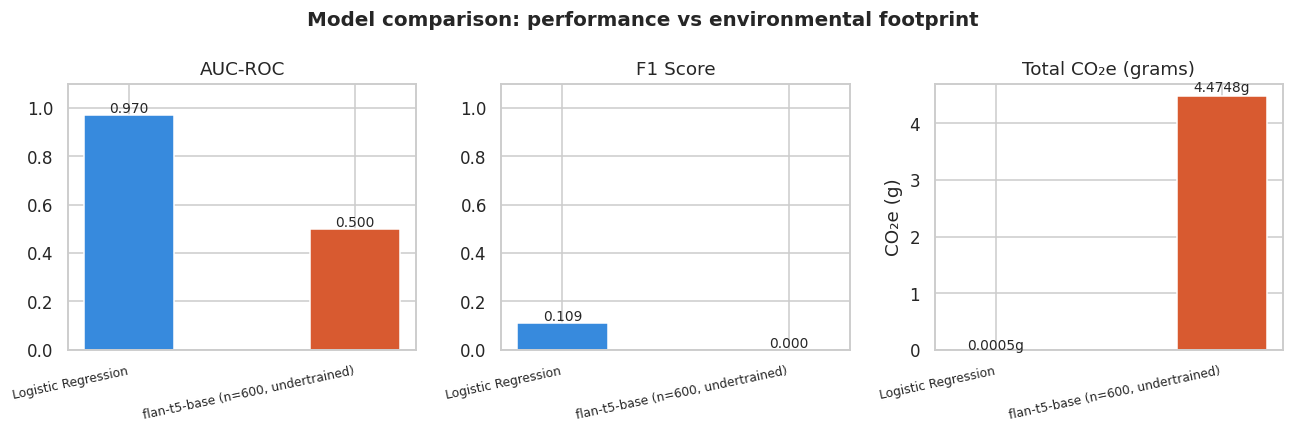

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
fig.suptitle('Model comparison: performance vs environmental footprint',
             fontsize=13, fontweight='bold')

models = results['Model'].tolist()
colors = ['#378ADD', '#D85A30']
x_pos  = np.arange(len(models))

# AUC
bars = axes[0].bar(x_pos, results['AUC'], color=colors, width=0.4)
axes[0].set_title('AUC-ROC')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(models, rotation=12, ha='right', fontsize=8)
axes[0].set_ylim(0, 1.1)
for bar, v in zip(bars, results['AUC']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

# F1
bars2 = axes[1].bar(x_pos, results['F1'], color=colors, width=0.4)
axes[1].set_title('F1 Score')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(models, rotation=12, ha='right', fontsize=8)
axes[1].set_ylim(0, 1.1)
for bar, v in zip(bars2, results['F1']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

# CO2e
bars3 = axes[2].bar(x_pos, results['CO2e_total_kg'] * 1000, color=colors, width=0.4)
axes[2].set_title('Total CO₂e (grams)')
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(models, rotation=12, ha='right', fontsize=8)
axes[2].set_ylabel('CO₂e (g)')
for bar, v in zip(bars3, results['CO2e_total_kg'] * 1000):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 v * 1.02, f'{v:.4f}g', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('final_comparison.png', dpi=130, bbox_inches='tight')
plt.show()

In [46]:
winner    = results.sort_values('score_hackathon', ascending=False).iloc[0]
runner    = results.sort_values('score_hackathon', ascending=False).iloc[1]
co2_ratio = runner['CO2e_total_kg'] / (winner['CO2e_total_kg'] + EPS)

print("=" * 65)
print("FINAL RECOMMENDATION")
print("=" * 65)
print(f"  Recommended : {winner['Model']}")
print(f"  Runner-up   : {runner['Model']}")
print(f"  AUC         : {winner['AUC']:.4f} vs {runner['AUC']:.4f}")
print(f"  F1          : {winner['F1']:.4f} vs {runner['F1']:.4f}")
print(f"  CO2e total  : {winner['CO2e_total_kg']*1000:.4f}g "
      f"vs {runner['CO2e_total_kg']*1000:.4f}g")
print(f"  CO2e ratio  : runner-up emits ~{co2_ratio:.0f}x more")
print(f"  Score       : {winner['score_hackathon']:.4f} "
      f"vs {runner['score_hackathon']:.4f}")
print(f"\n  Limitations:")
print(f"  - flan-t5 undertrained due to time constraints (nan val loss)")
print(f"  - flan-t5 inference on n=1,000 subsample only")
print(f"  - Despite limitations, CO2e cost is significantly higher")
print(f"  - Large LMs not justified for tabular fraud detection")
print("=" * 65)

FINAL RECOMMENDATION
  Recommended : Logistic Regression
  Runner-up   : flan-t5-base (n=600, undertrained)
  AUC         : 0.9698 vs 0.5000
  F1          : 0.1094 vs 0.0000
  CO2e total  : 0.0005g vs 4.4748g
  CO2e ratio  : runner-up emits ~9192x more
  Score       : 0.7000 vs -0.3000

  Limitations:
  - flan-t5 undertrained due to time constraints (nan val loss)
  - flan-t5 inference on n=1,000 subsample only
  - Despite limitations, CO2e cost is significantly higher
  - Large LMs not justified for tabular fraud detection


In [47]:
import json

summary = {
    "model": "google/flan-t5-base (fine-tuned)",
    "auc_roc": round(auc_t5, 4),
    "f1": round(f1_t5, 4),
    "precision": round(precision_t5, 4),
    "recall": round(recall_t5, 4),
    "train_time_s": round(runtime_t5_train, 2),
    "train_samples": 600,
    "co2_train_kg": round(co2_t5_train, 8),
    "co2_infer_per_1k_kg": round(co2_t5_inf / len(y_test_small) * 1000, 8),
    "model_parameters": sum(p.numel() for p in model.parameters()),
    "notes": (
        "Trained on 600 samples (300 fraud + 300 legit) due to time constraints. "
        "Inference evaluated on stratified subsample of 1,000 test rows. "
        "Validation loss was nan during training indicating undertrained model. "
        "Carbon estimated using TDP-based formula: kWh = runtime(h) x 0.065kW, "
        "CO2e = kWh x 0.233 kgCO2e/kWh (UK grid 2024)."
    )
}

with open("flan_t5_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print(json.dumps(summary, indent=2))
print("\n✅ Saved to flan_t5_summary.json")

{
  "model": "google/flan-t5-base (fine-tuned)",
  "auc_roc": 0.5,
  "f1": 0.0,
  "precision": 0.0,
  "recall": 0.0,
  "train_time_s": 1043.76,
  "train_samples": 600,
  "co2_train_kg": 0.00439102,
  "co2_infer_per_1k_kg": 8.376e-05,
  "model_parameters": 247577856,
  "notes": "Trained on 600 samples (300 fraud + 300 legit) due to time constraints. Inference evaluated on stratified subsample of 1,000 test rows. Validation loss was nan during training indicating undertrained model. Carbon estimated using TDP-based formula: kWh = runtime(h) x 0.065kW, CO2e = kWh x 0.233 kgCO2e/kWh (UK grid 2024)."
}

✅ Saved to flan_t5_summary.json
